# Notebook 3: Cellular States

This notebook examines whether cells show structure in their overall gene expression and whether that structure is associated with their perturbation labels. It does not yet define or measure perturbation response; that begins in Notebook 4.

Because all cells come from the same K562 cell line, any observed grouping should not automatically be interpreted as distinct cell types. Technical variation, cell-cycle state, or perturbation effects are possible explanations.

This notebook uses the preprocessed data from Notebook 2: 5752 cells, log-normalized expression, raw counts preserved in `adata.layers['counts']`, and 2000 highly variable genes.

The identity of `62(mod)_pBA581` as a negative control and the meaning of `nperts` remain unresolved.


## Setup

In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)

## Loading the preprocessed dataset

In [4]:
data_path = "F:/scRNA/adamson_pilot_preprocessed.h5ad"
adata = sc.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 5752 × 14690
    obs: 'perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mean_log_expression', 'variance_log_expression', 'dispersion', 'highly_variable'
    layers: 'counts'

## Choosing which genes go into the PCA


In [5]:
hvg_mask = adata.var["highly_variable"]
print("genes used for PCA:", hvg_mask.sum(), "of", adata.n_vars)

X_hvg = adata[:, hvg_mask].X
X_hvg = np.asarray(X_hvg.todense()) if sp.issparse(X_hvg) else np.asarray(X_hvg)
print("dense matrix for PCA:", X_hvg.shape)

genes used for PCA: 2000 of 14690
dense matrix for PCA: (5752, 2000)


## Centering



In [6]:
gene_means = X_hvg.mean(axis=0)
X_centered = X_hvg - gene_means

## Running PCA

In [7]:
n_components = 50
pca = PCA(n_components=n_components, random_state=0)
pcs = pca.fit_transform(X_centered)

adata.obsm["X_pca"] = pcs
print("PCA output shape:", pcs.shape)

PCA output shape: (5752, 50)


## How much variance do the components capture?


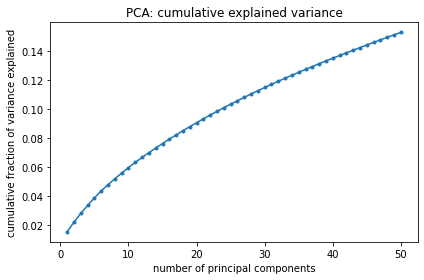

variance explained by PC1: 0.015628774
variance explained by PC2: 0.006622842
cumulative variance explained by first 10 PCs: 0.059838805


In [8]:
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o", markersize=3)
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative fraction of variance explained")
ax.set_title("PCA: cumulative explained variance")
plt.tight_layout()
plt.show()

print("variance explained by PC1:", explained[0])
print("variance explained by PC2:", explained[1])
print("cumulative variance explained by first 10 PCs:", explained[:10].sum())

## Do perturbation groups separate in PCA space?

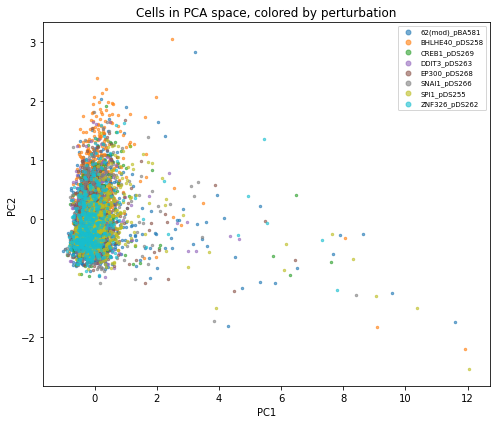

In [9]:
categories = adata.obs["perturbation"].cat.categories
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

fig, ax = plt.subplots(figsize=(7, 6))
for cat, color in zip(categories, colors):
    mask = adata.obs["perturbation"] == cat
    ax.scatter(pcs[mask.values, 0], pcs[mask.values, 1], s=6, alpha=0.6, color=color, label=str(cat))

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Cells in PCA space, colored by perturbation")
ax.legend(markerscale=2, fontsize=7, loc="best")
plt.tight_layout()
plt.show()

## Ruling out an obvious technical explanation



In [10]:
pc1_ncounts_corr = np.corrcoef(pcs[:, 0], adata.obs["ncounts"])[0, 1]
pc1_ngenes_corr = np.corrcoef(pcs[:, 0], adata.obs["ngenes"])[0, 1]
pc2_ncounts_corr = np.corrcoef(pcs[:, 1], adata.obs["ncounts"])[0, 1]
pc2_ngenes_corr = np.corrcoef(pcs[:, 1], adata.obs["ngenes"])[0, 1]

print("correlation of PC1 with total counts:", pc1_ncounts_corr)
print("correlation of PC1 with detected genes:", pc1_ngenes_corr)
print("correlation of PC2 with total counts:", pc2_ncounts_corr)
print("correlation of PC2 with detected genes:", pc2_ngenes_corr)

correlation of PC1 with total counts: -0.07089695075308537
correlation of PC1 with detected genes: -0.049673468016591886
correlation of PC2 with total counts: 0.10228468584877176
correlation of PC2 with detected genes: 0.11111652219354659


## What genes drive PC1 and PC2?



In [11]:
loadings = pca.components_
hvg_gene_names = adata.var_names[hvg_mask.values]

top_pc1 = pd.Series(loadings[0], index=hvg_gene_names).abs().sort_values(ascending=False).head(10)
top_pc2 = pd.Series(loadings[1], index=hvg_gene_names).abs().sort_values(ascending=False).head(10)

print("top genes contributing to PC1:")
print(top_pc1)
print()
print("top genes contributing to PC2:")
print(top_pc2)

top genes contributing to PC1:
gene_symbol
GDF15        0.346480
DDIT3        0.290293
SAT1         0.244666
SLC20A1      0.240661
JUNB         0.232752
PHLDA2       0.192030
TNFRSF12A    0.171114
IER3         0.168762
VGF          0.167941
CLCA1        0.163184
dtype: float32

top genes contributing to PC2:
gene_symbol
AIF1      0.747610
PHLDA2    0.336565
CLCA1     0.221284
CRYM      0.152824
PRSS1     0.128543
GDF15     0.125091
LST1      0.122430
PTPN7     0.120034
CD52      0.116815
ID1       0.105560
dtype: float32


## Saving the PCA result



In [12]:
output_path = "F:/scRNA/adamson_pilot_preprocessed.h5ad"
adata.write(output_path)
print("saved to", output_path)

saved to F:/scRNA/adamson_pilot_preprocessed.h5ad
